In [1]:
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import json
import statsmodels.formula.api as smf
from src.dynamic_pricing_data_loader import cargar_y_preparar_datos
from Tools.ExtractData import GetDataFromETL

In [2]:
Data= GetDataFromETL(True)
df=Data.Frame
df['FECHA_CORRIDA']=pd.to_datetime(df['FECHA_CORRIDA'])
df['HORA_SALIDA_CORRIDA']=pd.to_datetime(df['HORA_SALIDA_CORRIDA'])

El archivo JSON ha sido actualizado con las nuevas rutas.
Memoria usada antes: 5205.31 MB
Memoria usada después: 988.78 MB
Reducción: 81.0%


In [4]:
sorted(list(df.columns))

['AREA_VENTA',
 'AÑO',
 'BOLETOS_CANCEL',
 'BOLETOS_TOTALES',
 'BOLETOS_VEND',
 'CAPACIDAD_ASIENTOS_TRAMO',
 'CLASE_SERVICIO',
 'CUENTA_CORRIDA',
 'CV_ASIGN',
 'CV_CORRIDA',
 'DESC_DESCUENTO',
 'DESTINO',
 'DESTINO_CORRIDA',
 'DIAS_ANTICIPACION',
 'DIF_TARIF',
 'DISPONIBILIDAD_TRAMO',
 'EFECTIVO',
 'EMAIL',
 'EMPRESA',
 'FECHA_CORRIDA',
 'FECHA_OPERACION',
 'HORAS_ANTICIPACION',
 'HORA_DECIMAL',
 'HORA_OPERACION',
 'HORA_SALIDA_CORRIDA',
 'HORA_SALIDA_CORRIDA_',
 'HORA_SALIDA_ORIGEN_CORRIDA',
 'INGRESO_TEORICO_TRAMO',
 'INGRESO_TRANSP',
 'IVA_CANCEL',
 'IVA_TARIFA_BASE_TRAMO',
 'IVA_TRANSP',
 'IVA_VENDIDO',
 'KMS_ACUM_CORRIDA',
 'KMS_TRAMO',
 'MES',
 'NOMBRE_DIA_CORRIDA',
 'NOMBRE_DIA_OPERACION',
 'NOMBRE_PASAJERO',
 'NUM_ASIENTO',
 'OCUPACION_PUNTO',
 'OCUPACION_TRAMO',
 'OPERACION',
 'ORIGEN',
 'ORIGEN_CORRIDA',
 'ORIGEN_DESTINO',
 'PAGO_METODO',
 'PAX_BAJAN',
 'PAX_SUBEN',
 'PORCENT_PROMO',
 'TARIFA_BASE_TRAMO',
 'TARJETA',
 'TIEMPO_ANTICIPACION',
 'TIPO_BUS',
 'TIPO_CLIENTE',
 'TIP

In [105]:
dff=df.copy()

In [106]:
Df=dff[dff['FECHA_CORRIDA'].dt.year>=2025].copy()

In [107]:
#Df.to_excel('Datos2025.xlsx')

In [108]:
Df_d=Df[['ORIGEN_DESTINO','CV_CORRIDA','FECHA_OPERACION','FECHA_CORRIDA','VENTA','VENTA_TOTAL','NUM_ASIENTO','TOTAL_BOLETOS',
    'BOLETOS_CANCEL','BOLETOS_TOTALES','BOLETOS_VEND','DIAS_ANTICIPACION','HORAS_ANTICIPACION','HORA_OPERACION',
    'HORA_SALIDA_CORRIDA','HORA_DECIMAL','TIPO_CORRIDA','KMS_TRAMO','PAX_SUBEN','OCUPACION_TRAMO','CAPACIDAD_ASIENTOS_TRAMO']].copy()

Df_d=Df_d.drop_duplicates()

Df_d['VENTA_TOTAL']=Df_d['VENTA_TOTAL'].fillna(0)
Df_d['Año']= Df_d['FECHA_CORRIDA'].dt.year
Df_d= Df_d[(Df_d['BOLETOS_VEND']>0)].copy()
Df_d['CV_CORRIDA'] = Df_d['CV_CORRIDA'].astype(str)

Df_as= Df_d.groupby(['ORIGEN_DESTINO','FECHA_CORRIDA','CV_CORRIDA']).agg(
    NoAsientos=('CAPACIDAD_ASIENTOS_TRAMO','mean')
).reset_index()

Df_tot= Df_as.groupby(['ORIGEN_DESTINO','FECHA_CORRIDA']).agg(
    NoCorridas=('CV_CORRIDA','count'),
    Asientos_Ofertados=('NoAsientos','sum')
).reset_index()

In [109]:
# Definimos los puntos de corte en HORAS
# Nota: 24h=1d, 168h=1s, 720h=1m, 2160h=90d
bins = [
    -np.inf, 0, 1, 3, 6, 12, 24, 72, 168, 336, 720, 1440, 2160, np.inf
]

# Etiquetas claras para tu reporte
labels = [
    'Post-Salida',   # Menos de 0
    '0-1 hrs',       # Venta inmediata
    '1-3 hrs', 
    '3-6 hrs', 
    '6-12 hrs', 
    '12-24 hrs',     # Último día
    '1-3 días',      # 24-72 hrs
    '3-7 días',      # 1 semana
    '1-2 semanas', 
    '2-4 semanas',   # 1 mes
    '1-2 meses', 
    '2-3 meses',     # Hasta 90 días
    '+90 días'       # Por si acaso hay datos fuera de rango
]

# Creamos la columna en tu DataFrame original
Df_d['RANGO_ANTICIPACION'] = pd.cut(Df_d['HORAS_ANTICIPACION'], bins=bins, labels=labels)

# Verificamos cómo se distribuyen tus datos iniciales
print(Df_d['RANGO_ANTICIPACION'].value_counts().sort_index())

RANGO_ANTICIPACION
Post-Salida     42829
0-1 hrs         73591
1-3 hrs         62594
3-6 hrs         35249
6-12 hrs        46377
12-24 hrs       69736
1-3 días       102381
3-7 días        72016
1-2 semanas     38247
2-4 semanas     23126
1-2 meses        7505
2-3 meses        1760
+90 días           24
Name: count, dtype: int64


In [110]:
import plotly.express as px

conteo = Df_d['RANGO_ANTICIPACION'].value_counts().sort_index().reset_index()
conteo.columns = ['RANGO_ANTICIPACION','COUNT']

fig = px.bar(
    conteo,
    x='RANGO_ANTICIPACION',
    y='COUNT',
    title="Distribución de RANGO_ANTICIPACION",
    labels={'RANGO_ANTICIPACION':'Rango de anticipación','COUNT':'Número de boletos'}
)
fig.show()

In [111]:
# Unimos Df_d con Df_tot usando las columnas llave
Df_final = Df_d.merge(Df_tot, on=['ORIGEN_DESTINO', 'FECHA_CORRIDA'], how='left')
Df_final['Asientos_Ofertados']=np.round(Df_final['Asientos_Ofertados'])

In [112]:
Ddf_d=Df_d.copy()

orden_rangos = ['+90 días', '2-3 meses', '1-2 meses', '2-4 semanas', '1-2 semanas', 
                '3-7 días', '1-3 días', '12-24 hrs', '6-12 hrs', '3-6 hrs', '1-3 hrs', '0-1 hrs', 'Post-Salida']
Ddf_d['RANGO_ANTICIPACION'] = pd.Categorical(Df_d['RANGO_ANTICIPACION'], categories=orden_rangos, ordered=True)

Ddf_d= Ddf_d[Ddf_d['RANGO_ANTICIPACION']!='Post-Salida'].copy()
# Agrupamos incluyendo ORIGEN_DESTINO
df_agrupado = Ddf_d.groupby(['ORIGEN_DESTINO', 'CV_CORRIDA','FECHA_CORRIDA','RANGO_ANTICIPACION'], observed=True).agg({
    'BOLETOS_VEND': 'sum',
    'CAPACIDAD_ASIENTOS_TRAMO': 'max' 
}).reset_index()

# Ordenar físicamente: Ruta -> Corrida -> Fecha -> Tiempo (Rango)
df_agrupado = df_agrupado.sort_values([
    'ORIGEN_DESTINO', 
    'CV_CORRIDA', 
    'FECHA_CORRIDA', 
    'RANGO_ANTICIPACION'
])

# El acumulado sigue igual (necesita la llave única de la corrida)
df_agrupado['VENTA_ACUMULADA'] = df_agrupado.groupby(['CV_CORRIDA', 'FECHA_CORRIDA'])['BOLETOS_VEND'].cumsum()

# Cálculo de porcentaje
df_agrupado['OCUPACION_ACUMULADA_%'] = (df_agrupado['VENTA_ACUMULADA'] / df_agrupado['CAPACIDAD_ASIENTOS_TRAMO']) * 100

df_agrupado.head(25)

,ORIGEN_DESTINO,CV_CORRIDA,FECHA_CORRIDA,RANGO_ANTICIPACION,BOLETOS_VEND,CAPACIDAD_ASIENTOS_TRAMO,VENTA_ACUMULADA,OCUPACION_ACUMULADA_%
0,GDLJ-MEXN,1055007,2025-01-13,6-12 hrs,2.0,33,2.0,6.060606
1,GDLJ-MEXN,1055007,2025-01-13,3-6 hrs,1.0,33,3.0,9.090909
2,GDLJ-MEXN,1055007,2025-01-13,1-3 hrs,1.0,33,4.0,12.121212
3,GDLJ-MEXN,1055007,2025-04-11,1-3 días,3.0,33,3.0,9.090909
4,GDLJ-MEXN,1055007,2025-04-11,12-24 hrs,6.0,33,9.0,27.272727
5,GDLJ-MEXN,1055007,2025-04-11,6-12 hrs,6.0,33,15.0,45.454545
6,GDLJ-MEXN,1055007,2025-04-11,1-3 hrs,1.0,33,16.0,48.484848
7,GDLJ-MEXN,1055007,2025-04-11,0-1 hrs,7.0,33,23.0,69.696970
8,GDLJ-MEXN,1055007,2025-04-16,1-3 días,13.0,35,13.0,37.142857
9,GDLJ-MEXN,1055007,2025-04-16,12-24 hrs,1.0,35,14.0,40.000000


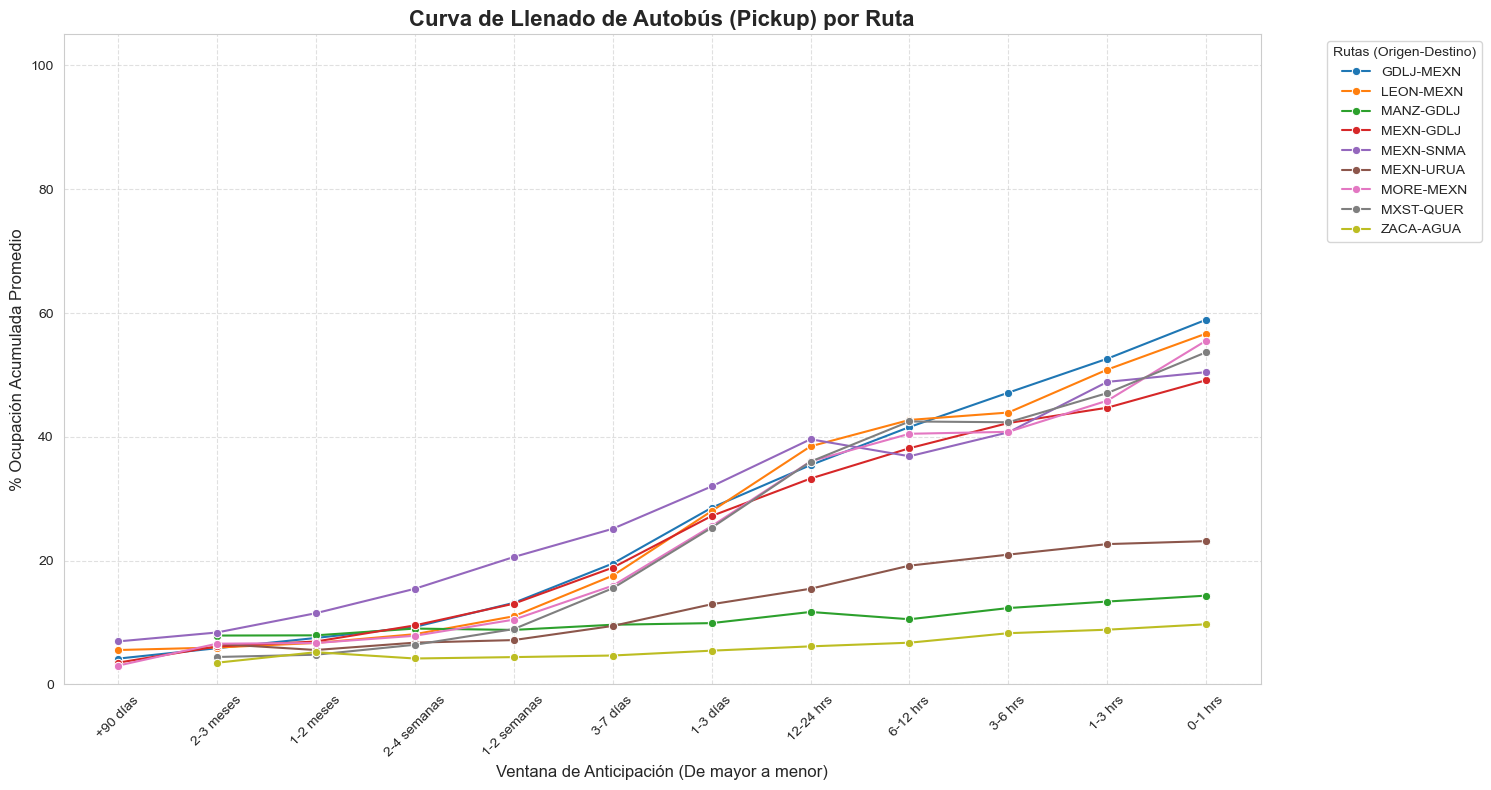

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparación de los datos para el gráfico
# Agrupamos por Ruta y Rango para obtener el promedio de la ocupación acumulada
df_plot = df_agrupado.groupby(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'], observed=True)['OCUPACION_ACUMULADA_%'].mean().reset_index()

# IMPORTANTE: Aseguramos que el eje X mantenga el orden lógico de los rangos
# Esto evita que el gráfico ordene alfabéticamente (ej: que ponga '0-1 hrs' antes que '1-2 meses')
df_plot['RANGO_ANTICIPACION'] = df_plot['RANGO_ANTICIPACION'].astype(str)
orden_final = [r for r in orden_rangos if r in df_plot['RANGO_ANTICIPACION'].unique()]

# 2. Configuración estética
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# 3. Dibujar las líneas
# Si tienes demasiadas rutas, aquí podrías filtrar: df_plot[df_plot['ORIGEN_DESTINO'].isin(['RUTA1', 'RUTA2'])]
plot = sns.lineplot(
    data=df_plot, 
    x='RANGO_ANTICIPACION', 
    y='OCUPACION_ACUMULADA_%', 
    hue='ORIGEN_DESTINO', 
    marker='o',
    sort=False # Mantiene el orden de nuestra lista 'orden_rangos'
)

# 4. Ajustes finales de formato
plt.title('Curva de Llenado de Autobús (Pickup) por Ruta', fontsize=16, fontweight='bold')
plt.xlabel('Ventana de Anticipación (De mayor a menor)', fontsize=12)
plt.ylabel('% Ocupación Acumulada Promedio', fontsize=12)

# Forzamos el orden en el eje X para que se lea de izquierda a derecha (el pasado hacia el presente)
plt.xticks(ticks=range(len(orden_final)), labels=orden_final, rotation=45)

plt.ylim(0, 105) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Rutas (Origen-Destino)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [122]:
df_plot

,ORIGEN_DESTINO,RANGO_ANTICIPACION,OCUPACION_ACUMULADA_%
0,GDLJ-MEXN,+90 días,4.166667
1,GDLJ-MEXN,2-3 meses,5.847645
2,GDLJ-MEXN,1-2 meses,7.503731
3,GDLJ-MEXN,2-4 semanas,9.283746
4,GDLJ-MEXN,1-2 semanas,13.172389
...,...,...,...
99,ZACA-AGUA,12-24 hrs,6.147222
100,ZACA-AGUA,6-12 hrs,6.739119
101,ZACA-AGUA,3-6 hrs,8.275194
102,ZACA-AGUA,1-3 hrs,8.840472


In [114]:
# 1. Agrupamos por Ruta y Rango para ver el promedio de boletos vendidos en ese espacio de tiempo
df_oro = df_agrupado.groupby(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'], observed=True)['BOLETOS_VEND'].mean().reset_index()

# 2. Encontramos el rango con el valor máximo para cada Origen-Destino
idx_max = df_oro.groupby('ORIGEN_DESTINO')['BOLETOS_VEND'].idxmax()
df_horas_oro = df_oro.loc[idx_max].sort_values('BOLETOS_VEND', ascending=False)

# 3. Renombramos para que sea claro el reporte
df_horas_oro.columns = ['Ruta', 'Rango de Mayor Venta', 'Promedio Boletos en ese Rango']
print(df_horas_oro)

         Ruta Rango de Mayor Venta  Promedio Boletos en ese Rango
18  LEON-MEXN             1-3 días                       4.631269
6   GDLJ-MEXN             1-3 días                       4.231385
41  MEXN-GDLJ             1-3 días                       4.220653
76  MORE-MEXN             1-3 días                       4.132065
87  MXST-QUER             1-3 días                       3.890925
53  MEXN-SNMA             1-3 días                       3.819444
26  MANZ-GDLJ          2-4 semanas                       2.608824
64  MEXN-URUA             1-3 días                       2.441255
94  ZACA-AGUA            1-2 meses                       1.823529


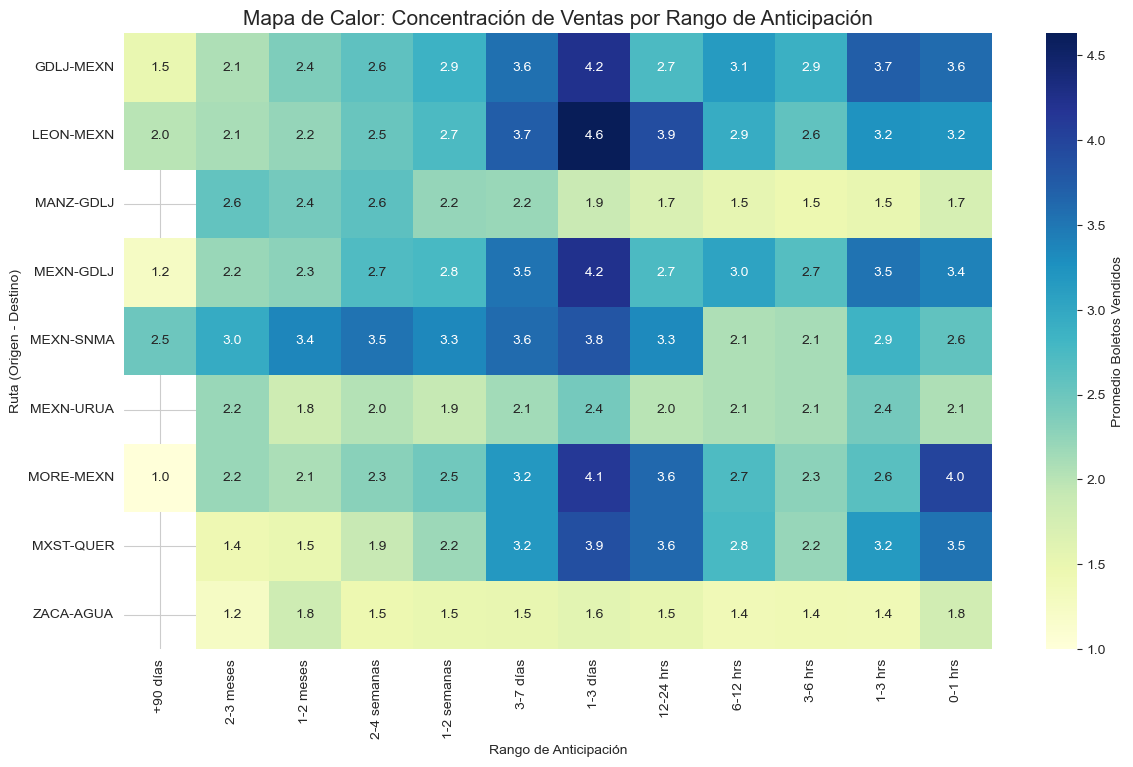

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivotamos los datos para el Heatmap
df_pivot = df_oro.pivot(index='ORIGEN_DESTINO', columns='RANGO_ANTICIPACION', values='BOLETOS_VEND')

plt.figure(figsize=(14, 8))
sns.heatmap(df_pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Promedio Boletos Vendidos'})

plt.title('Mapa de Calor: Concentración de Ventas por Rango de Anticipación', fontsize=15)
plt.xlabel('Rango de Anticipación')
plt.ylabel('Ruta (Origen - Destino)')
plt.show()

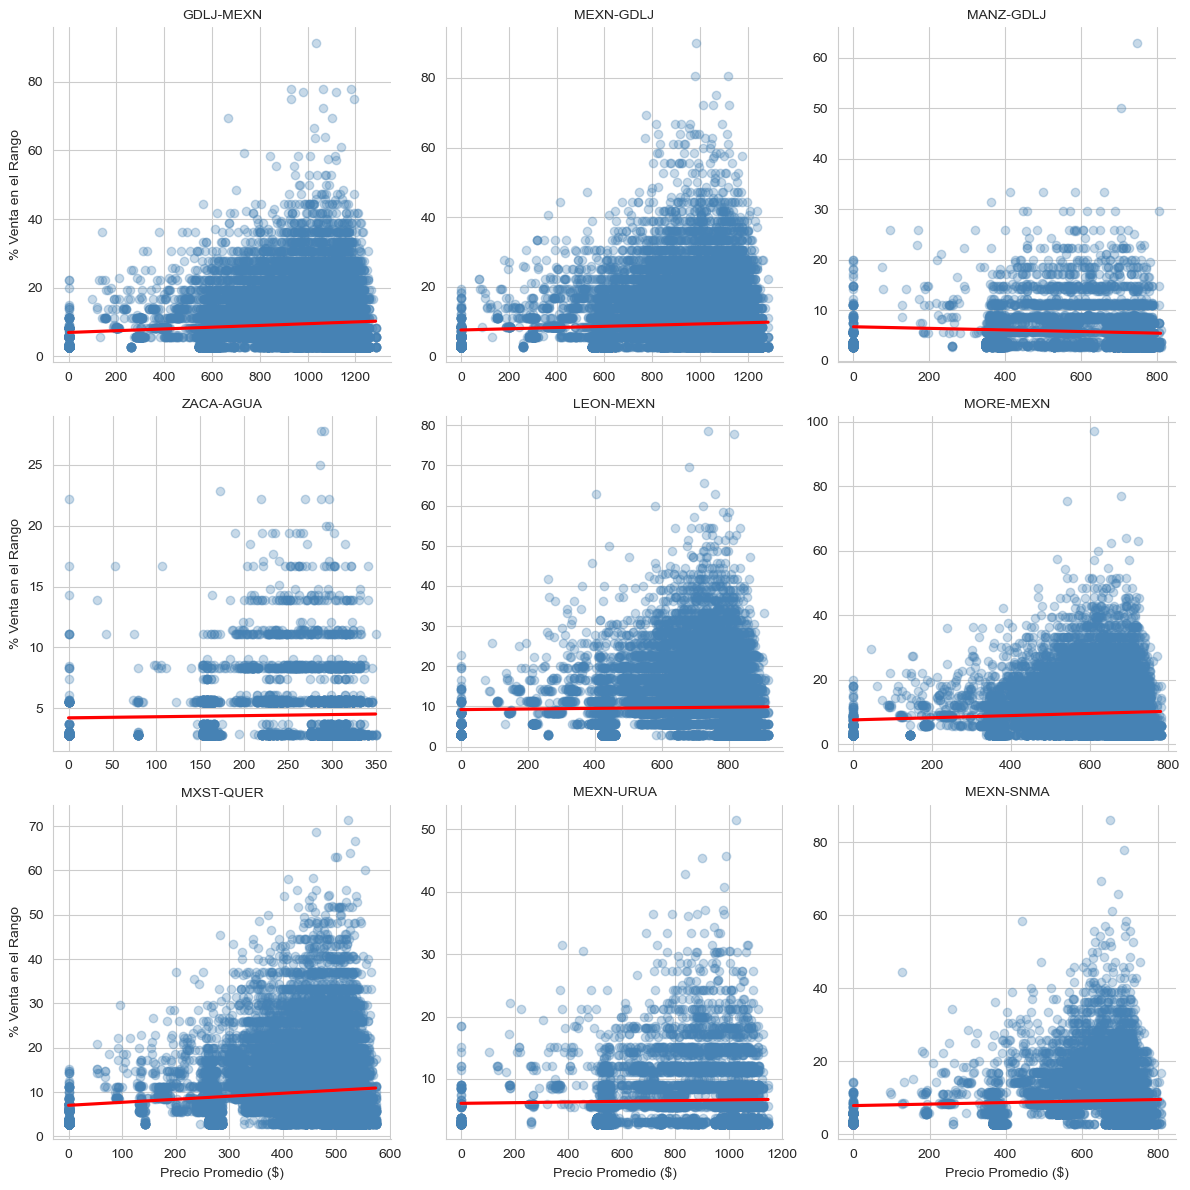

In [117]:
Ddf_d=Df_d.copy()

orden_rangos = ['+90 días', '2-3 meses', '1-2 meses', '2-4 semanas', '1-2 semanas', 
                '3-7 días', '1-3 días', '12-24 hrs', '6-12 hrs', '3-6 hrs', '1-3 hrs', '0-1 hrs', 'Post-Salida']
Ddf_d['RANGO_ANTICIPACION'] = pd.Categorical(Df_d['RANGO_ANTICIPACION'], categories=orden_rangos, ordered=True)

Ddf_d= Ddf_d[Ddf_d['RANGO_ANTICIPACION']!='Post-Salida'].copy()

# 1. Agrupamos incluyendo la métrica de ingresos (VENTA)
df_precio = Ddf_d.groupby(['ORIGEN_DESTINO', 'CV_CORRIDA', 'FECHA_CORRIDA', 'RANGO_ANTICIPACION'], observed=True).agg({
    'BOLETOS_VEND': 'sum',
    'VENTA': 'sum',  # Total de ingresos en ese rango
    'CAPACIDAD_ASIENTOS_TRAMO': 'mean'
}).reset_index()

# 2. Calculamos el Precio Promedio por Boleto (Tarifa Promedio)
# Usamos np.where para evitar división por cero si en un rango no hubo ventas
df_precio['PRECIO_PROMEDIO'] = np.where(
    df_precio['BOLETOS_VEND'] > 0, 
    df_precio['VENTA'] / df_precio['BOLETOS_VEND'], 
    0
)

# 3. Traemos el acumulado (que ya tenías)
df_precio = df_precio.sort_values(['CV_CORRIDA', 'FECHA_CORRIDA', 'RANGO_ANTICIPACION'])
df_precio['VENTA_ACUMULADA'] = df_precio.groupby(['CV_CORRIDA', 'FECHA_CORRIDA'])['BOLETOS_VEND'].cumsum()
df_precio['OCUPACION_ACUMULADA_%'] = (df_precio['VENTA_ACUMULADA'] / df_precio['CAPACIDAD_ASIENTOS_TRAMO']) * 100

# Calculamos cuánto aumentó la ocupación en cada rango (Venta incremental)
df_precio['INCREMENTO_OCUPACION'] = (df_precio['BOLETOS_VEND'] / df_precio['CAPACIDAD_ASIENTOS_TRAMO']) * 100

import seaborn as sns
import matplotlib.pyplot as plt

# Filtramos solo registros con venta para no ensuciar el gráfico con ceros
df_scatter = df_precio[df_precio['BOLETOS_VEND'] > 0].copy()

# Creamos la cuadrícula de gráficos (puedes limitar a las rutas principales)
# col_wrap=3 sirve para que ponga 3 gráficas por fila
g = sns.FacetGrid(df_scatter, col="ORIGEN_DESTINO", col_wrap=3, height=4, sharex=False, sharey=False)

# Añadimos los puntos y una línea de regresión (fit_reg=True) para ver la tendencia
g.map(sns.regplot, "PRECIO_PROMEDIO", "INCREMENTO_OCUPACION", 
      scatter_kws={'alpha':0.3, 'color':'steelblue'}, 
      line_kws={'color':'red'})

g.set_titles("{col_name}")
g.set_axis_labels("Precio Promedio ($)", "% Venta en el Rango")
plt.tight_layout()
plt.show()



Apenas me di cuenta, que tu validacion para ver si la curva de ocupacion se mueve con el precio, depende directamente de que haya un esquema de precios variables de menor a mayor en dias de anticipacion, es decir, que mientras mas anticipada sea tu compra mas barato sale, mi argumento es que si no es de esta forma, nunca vas a tener una correlación negativa fuerte, con un esquema de precios fijos el precio promedio pues solo depende del ingreso neto que es proporcional a la cantidad de boletos que compres pero la variacion se obtiene directamente de los descuentos por tipo de pasajero.

In [119]:
# Calculamos la correlación por cada grupo de ORIGEN_DESTINO
correlaciones = df_scatter.groupby('ORIGEN_DESTINO').apply(
    lambda x: x['PRECIO_PROMEDIO'].corr(x['INCREMENTO_OCUPACION'])
).reset_index()

correlaciones.columns = ['ORIGEN_DESTINO', 'CORRELACION_PRECIO_VENTA']
correlaciones = correlaciones.sort_values('CORRELACION_PRECIO_VENTA')

print("Rutas más sensibles al precio (Correlación más negativa):")
print(correlaciones)

Rutas más sensibles al precio (Correlación más negativa):
  ORIGEN_DESTINO  CORRELACION_PRECIO_VENTA
2      MANZ-GDLJ                 -0.072777
1      LEON-MEXN                  0.018276
8      ZACA-AGUA                  0.026766
5      MEXN-URUA                  0.029284
4      MEXN-SNMA                  0.043993
3      MEXN-GDLJ                  0.062521
6      MORE-MEXN                  0.068353
0      GDLJ-MEXN                  0.094395
7      MXST-QUER                  0.100823


Las correlaciones son bajas, por lo que podemos decir que el precio no influye en la compra con anticipación

In [121]:
# 1. Calculamos métricas por ruta
df_estrategia = df_scatter.groupby('ORIGEN_DESTINO', observed=True).agg({
    'PRECIO_PROMEDIO': ['std', 'mean'],     # Variabilidad de precio y precio base
    'INCREMENTO_OCUPACION': ['std', 'mean'], # Variabilidad de venta y venta base
    'BOLETOS_VEND': 'sum'                    # Volumen total
}).reset_index()

# Aplanamos los nombres de las columnas
df_estrategia.columns = ['RUTA', 'STD_PRECIO', 'MEAN_PRECIO', 'STD_VENTA', 'MEAN_VENTA', 'TOTAL_VENDIDO']

# 2. Calculamos la Correlación de Pearson (Sensibilidad)
def calcular_corr(group):
    if len(group) > 5: # Necesitamos al menos 5 puntos para que sea estadísticamente serio
        return group['PRECIO_PROMEDIO'].corr(group['INCREMENTO_OCUPACION'])
    return 0

corrs = df_scatter.groupby('ORIGEN_DESTINO', observed=True).apply(calcular_corr).reset_index()
corrs.columns = ['RUTA', 'SENSIBILIDAD_PRECIO']

# 3. Unimos todo
df_final = pd.merge(df_estrategia, corrs, on='RUTA')

# 4. Clasificación Automática
def clasificar_ruta(row):
    if row['SENSIBILIDAD_PRECIO'] < -0.5:
        return "ALTA ELASTICIDAD (Candidata a Precios Dinámicos)"
    elif row['SENSIBILIDAD_PRECIO'] > -0.2 and row['STD_VENTA'] > row['MEAN_VENTA']*0.5:
        return "DEMANDA ERRÁTICA (Revisar Horarios/Competencia)"
    else:
        return "INELÁSTICA (Mantener o Subir Precios)"

df_final['ESTRATEGIA_RECOMENDADA'] = df_final.apply(clasificar_ruta, axis=1)

# Ver el Top de rutas para Precios Dinámicos
print(df_final.sort_values('SENSIBILIDAD_PRECIO'))

        RUTA  STD_PRECIO  MEAN_PRECIO  STD_VENTA  MEAN_VENTA  TOTAL_VENDIDO  \
2  MANZ-GDLJ  189.944962   591.275269   4.133231    5.791861        13371.0   
1  LEON-MEXN  183.166611   695.168701   7.562214    9.721411        87865.0   
8  ZACA-AGUA   82.132309   247.122665   2.767856    4.441877         9844.0   
5  MEXN-URUA  257.401764   837.482239   4.761728    6.545046        20499.0   
4  MEXN-SNMA  154.363632   631.874451   7.289611    9.136511        40089.0   
3  MEXN-GDLJ  271.627563   929.542053   7.571051    9.203947       106143.0   
6  MORE-MEXN  152.792969   584.932556   7.432282    9.529060        72459.0   
0  GDLJ-MEXN  271.079254   921.515564   7.334530    9.287432        93220.0   
7  MXST-QUER  115.986626   431.681305   7.826222    9.934894        89116.0   

   SENSIBILIDAD_PRECIO                           ESTRATEGIA_RECOMENDADA  
2            -0.072777  DEMANDA ERRÁTICA (Revisar Horarios/Competencia)  
1             0.018276  DEMANDA ERRÁTICA (Revisar Horarios/Co

In [123]:
import pandas as pd
import numpy as np

# 1. Tu Base de Comparación (Datos Reales que ya calculaste)
# Usamos el df_plot que generaste con el promedio de ocupación acumulada
df_base_comparacion = df_plot.rename(columns={'OCUPACION_ACUMULADA_%': 'OCUPACION_IDEAL_%'})

# 2. Generamos una Muestra de Datos de "HOY" (Df_actual)
# Simulamos 3 corridas que están activas en este momento en el sistema
data_hoy = {
    'ORIGEN_DESTINO': [
        df_base_comparacion['ORIGEN_DESTINO'].iloc[0], # Tomamos una ruta real de tus datos
        df_base_comparacion['ORIGEN_DESTINO'].iloc[1] if len(df_base_comparacion) > 1 else 'RUTA_EJEMPLO',
        df_base_comparacion['ORIGEN_DESTINO'].iloc[0]  # Otra corrida de la misma ruta
    ],
    'CV_CORRIDA': ['CORR-101', 'CORR-202', 'CORR-303'],
    'RANGO_ANTICIPACION': [
        '1-3 días', 
        '12-24 hrs', 
        '3-7 días'
    ],
    # Simulamos ocupaciones reales para ver los disparadores
    'OCUPACION_ACUMULADA_%': [10.5, 58.0, 45.0] 
}
Df_actual = pd.DataFrame(data_hoy)

# 3. El Motor del Trigger: Comparación vs Histórico
df_analisis_hoy = pd.merge(
    Df_actual, 
    df_base_comparacion, 
    on=['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'], 
    how='left'
)

# 4. Cálculo de la Brecha (Gap)
# Desviación = Realidad de hoy - Promedio histórico
df_analisis_hoy['DESVIACION_PTS'] = df_analisis_hoy['OCUPACION_ACUMULADA_%'] - df_analisis_hoy['OCUPACION_IDEAL_%']

# 5. Definición de Reglas de Acción (El Semáforo)
def definir_accion(row):
    if pd.isna(row['OCUPACION_IDEAL_%']):
        return '⚪ SIN HISTÓRICO'
    elif row['DESVIACION_PTS'] < -12: # Más de 12 puntos abajo
        return '🔴 OFERTAR (Venta Lenta)'
    elif row['DESVIACION_PTS'] > 15:  # Más de 15 puntos arriba
        return '🟢 SUBIR PRECIO (Alta Demanda)'
    else:
        return '🟡 NORMAL (Mantener)'

df_analisis_hoy['ACCION_RECOMENDADA'] = df_analisis_hoy.apply(definir_accion, axis=1)

# 6. Mostrar Resultados
print("--- ANÁLISIS DE DISPARADORES DE PRECIO ---")
display(df_analisis_hoy[['ORIGEN_DESTINO', 'CV_CORRIDA', 'RANGO_ANTICIPACION', 
                        'OCUPACION_ACUMULADA_%', 'OCUPACION_IDEAL_%', 'ACCION_RECOMENDADA']])

--- ANÁLISIS DE DISPARADORES DE PRECIO ---


,ORIGEN_DESTINO,CV_CORRIDA,RANGO_ANTICIPACION,OCUPACION_ACUMULADA_%,OCUPACION_IDEAL_%,ACCION_RECOMENDADA
0,GDLJ-MEXN,CORR-101,1-3 días,10.5,28.534801,🔴 OFERTAR (Venta Lenta)
1,GDLJ-MEXN,CORR-202,12-24 hrs,58.0,35.434275,🟢 SUBIR PRECIO (Alta Demanda)
2,GDLJ-MEXN,CORR-303,3-7 días,45.0,19.524519,🟢 SUBIR PRECIO (Alta Demanda)
